In [7]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay


In [8]:
file_path = "./merged_all.csv"

try:
    df = pd.read_csv(file_path)
    print(f"Loaded Overath Data: {len(df)} rows")
except Exception as e:
    print(f"Error: {e}")
    df = pd.DataFrame()

Loaded Overath Data: 17467 rows


In [9]:
target_col = 'binding_binary'

# ============================================================
# Klassifizierung Overath-Daten (target_col = "binder")
# - Train/Test Split
# - Baselines: Logistic Regression, RandomForest, XGBoost (optional)
# - Preprocessing: Numeric + OneHot für kategoriale Features
# - Evaluation: ROC-AUC, PR-AUC, Precision/Recall/F1, Confusion Matrix
# - Feature Importance (für RF) + Coefficients (für LogReg)
# ============================================================

# Basic checks
assert target_col in df.columns, f"'{target_col}' nicht in Spalten vorhanden."
print("Shape:", df.shape)
print("Target value counts:\n", df[target_col].value_counts(dropna=False))

# Ensure binary (bool/int)
df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
df = df.dropna(subset=[target_col])
y = df[target_col].astype(int)

# ------------------------
# 2) Feature selection
# ------------------------
# Entferne explizit IDs/Metadaten/Sequenzen
drop_cols = [ target_col,
    "binder_id","target_id","source",
    "binder_chain","target_chains","target_chain_range","msa_info",
    "A_seq","B_seq","target_subchain_B_seq","target_subchain_C_seq","target_subchain_D_seq"
]
DROP_COLS_CLASSIFICATION = [
    target_col,
    "binding_strength",
    "kd_M",
    "pKD",
    "sequence",
    "dataset",
    "source",
    "source_dataset",
    "target",
    "binder",
    "assay_method",
    "structure_method",
    "design_method",
]
drop_cols = [c for c in drop_cols if c in df.columns]

X = df.drop(columns=drop_cols, errors="ignore")


Shape: (17467, 20)
Target value counts:
 binding_binary
1.0    11064
0.0     5878
NaN      525
Name: count, dtype: int64



Nutze alle Features (Baseline nicht vollständig verfügbar).

#Numeric: 9  #Categorical: 9

=== Logistic Regression ===
ROC-AUC: 0.9947
PR-AUC : 0.9976

Classification report:
               precision    recall  f1-score   support

           0     0.9325    0.9932    0.9619      2351
           1     0.9963    0.9618    0.9787      4426

    accuracy                         0.9727      6777
   macro avg     0.9644    0.9775    0.9703      6777
weighted avg     0.9741    0.9727    0.9729      6777

Confusion matrix:
 [[2335   16]
 [ 169 4257]]


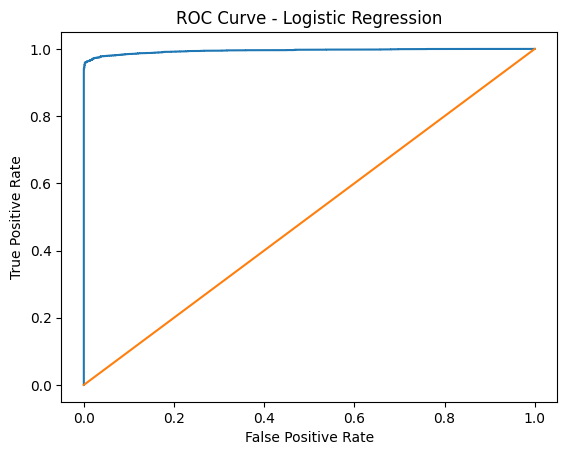

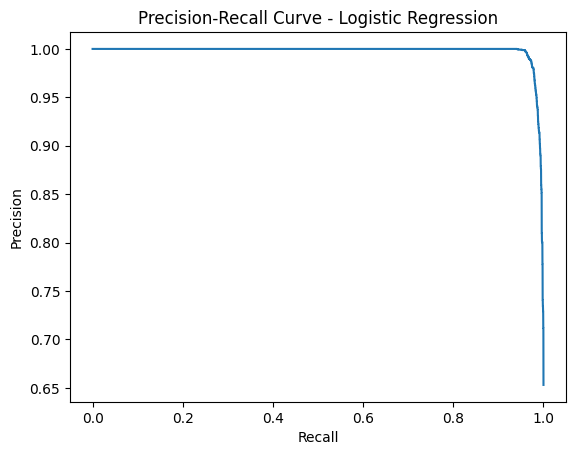


=== Random Forest ===
ROC-AUC: 0.9956
PR-AUC : 0.9980

Classification report:
               precision    recall  f1-score   support

           0     0.9458    0.9940    0.9693      2351
           1     0.9967    0.9697    0.9831      4426

    accuracy                         0.9782      6777
   macro avg     0.9713    0.9819    0.9762      6777
weighted avg     0.9791    0.9782    0.9783      6777

Confusion matrix:
 [[2337   14]
 [ 134 4292]]


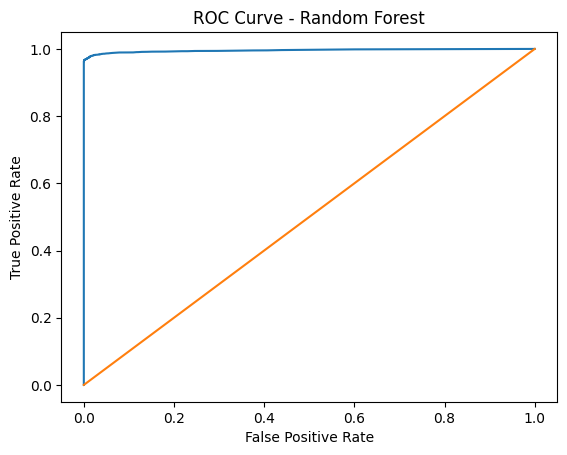

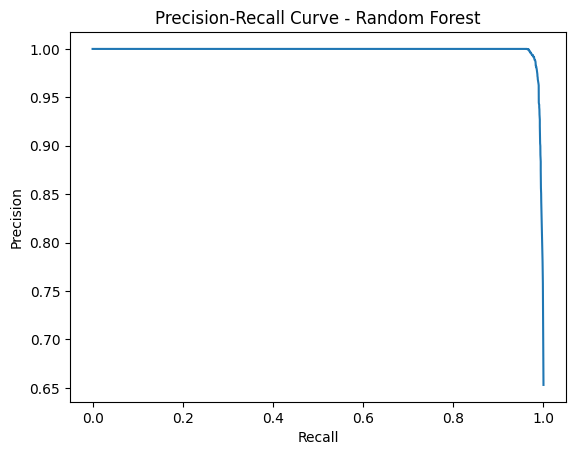


=== 5-fold CV: Logistic Regression ===
roc_auc: 0.9944 ± 0.0013
avg_precision: 0.9975 ± 0.0006
f1: 0.9788 ± 0.0034
precision: 0.9963 ± 0.0008
recall: 0.9619 ± 0.0060

=== 5-fold CV: Random Forest ===
roc_auc: 0.9959 ± 0.0009
avg_precision: 0.9981 ± 0.0004
f1: 0.9838 ± 0.0016
precision: 0.9974 ± 0.0009
recall: 0.9705 ± 0.0033


In [10]:
metrics = {
        'AF3 ipSAE (Proposed)':     'af3_ipSAE_min',           
        'AF3 pLDDT (Global)':       'af3_plddt_binder',        
        'AF2 pLDDT (Baseline)':     'af2_plddt_binder', 
        'Rosetta Energy (Physics)': 'af3_rosetta_binder_score',
        'AF3 pDockQ (Interface)':   'af3_pDockQ2_max'
}

available_baseline = [c for c in metrics if c in X.columns]

# Wenn Baseline-Features vorhanden: nutze sie, sonst nutze alle numerischen Spalten
if len(available_baseline) >= 2:
    X = X[available_baseline].copy()
    print("\nNutze Baseline-Feature-Set:", available_baseline)
else:
    print("\nNutze alle Features (Baseline nicht vollständig verfügbar).")

# Identify numeric/categorical
numeric_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()
categorical_cols = [c for c in X.columns if c not in numeric_cols]

print("\n#Numeric:", len(numeric_cols), " #Categorical:", len(categorical_cols))

# ------------------------
# 3) Preprocessing pipeline
# ------------------------
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False))  # with_mean=False ist robust für sparse matrices
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ],
    remainder="drop"
)

# ------------------------
# 4) Models
# ------------------------
logreg = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",  # wichtig bei Imbalance
    solver="lbfgs"
)

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    class_weight="balanced_subsample",
    n_jobs=-1
)

# Pipelines
pipe_logreg = Pipeline(steps=[("preprocess", preprocess), ("model", logreg)])
pipe_rf = Pipeline(steps=[("preprocess", preprocess), ("model", rf)])

# ------------------------
# 5) Train/test split + evaluation
# ------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

def evaluate_model(pipe, X_train, y_train, X_test, y_test, name="model"):
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    roc = roc_auc_score(y_test, proba)
    pr = average_precision_score(y_test, proba)

    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {roc:.4f}")
    print(f"PR-AUC : {pr:.4f}")
    print("\nClassification report:\n", classification_report(y_test, pred, digits=4))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred))

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0,1],[0,1])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.show()

    # PR curve
    prec, rec, _ = precision_recall_curve(y_test, proba)
    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.show()

    return pipe

pipe_logreg_fitted = evaluate_model(pipe_logreg, X_train, y_train, X_test, y_test, name="Logistic Regression")
pipe_rf_fitted     = evaluate_model(pipe_rf, X_train, y_train, X_test, y_test, name="Random Forest")

# ------------------------
# 6) Cross-validation (robuster)
# ------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "avg_precision": "average_precision",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall"
}

def cv_summary(pipe, X, y, name="model"):
    res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_train_score=False)
    print(f"\n=== 5-fold CV: {name} ===")
    for k, v in res.items():
        if k.startswith("test_"):
            print(f"{k.replace('test_','')}: {np.mean(v):.4f} ± {np.std(v):.4f}")

cv_summary(pipe_logreg, X, y, name="Logistic Regression")
cv_summary(pipe_rf, X, y, name="Random Forest")

# ------------------------
# 7) Optional: Feature interpretability
# ------------------------
# Für LogReg: Koeffizienten (nur sinnvoll bei nicht zu vielen OneHot-Features)
# Für RF: Feature importances (nur für numerische Baseline-Features wirklich interpretierbar)

# Wenn du Baseline-Features nutzt (nur numeric), kannst du direkte Importances anzeigen:
if len(categorical_cols) == 0 and len(X.columns) <= 50:
    # LogReg coefficients
    try:
        coef = pipe_logreg_fitted.named_steps["model"].coef_.ravel()
        coef_df = pd.DataFrame({"feature": X.columns, "coef": coef}).sort_values("coef", ascending=False)
        print("\nTop positive LogReg coefficients:\n", coef_df.head(10))
        print("\nTop negative LogReg coefficients:\n", coef_df.tail(10))
    except Exception as e:
        print("LogReg coefficient extraction failed:", e)
        # RF importances
    try:
        imp = pipe_rf_fitted.named_steps["model"].feature_importances_
        imp_df = pd.DataFrame({"feature": X.columns, "importance": imp}).sort_values("importance", ascending=False)
        print("\nTop RF importances:\n", imp_df.head(15))
    except Exception as e:
        print("RF importance extraction failed:", e)



Numeric feature matrix shape: (16942, 9)
Chosen features for plot: ('kd_M', 'pKD')


KeyboardInterrupt: 

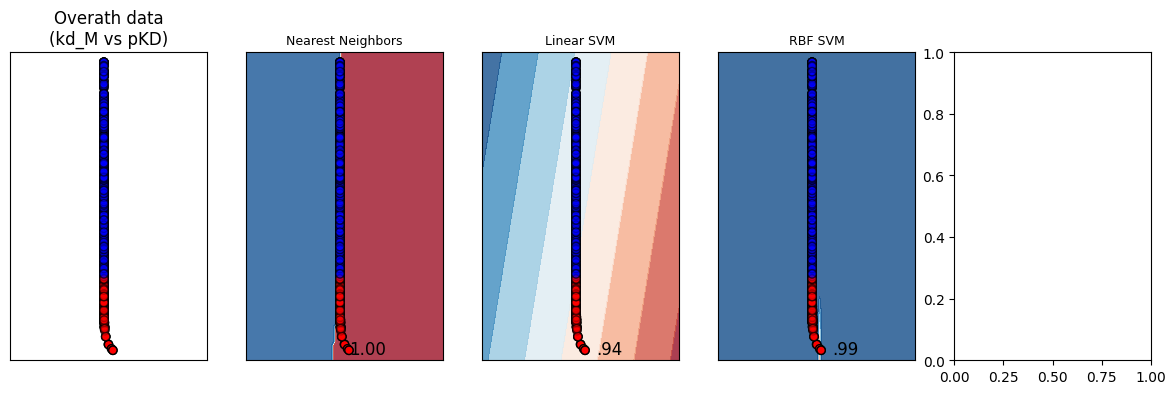

In [11]:
# drop remaining non-numeric columns (prevents str/float errors)
X_all = X.select_dtypes(include=[np.number, "bool"]).copy()

print("Numeric feature matrix shape:", X_all.shape)

preferred_pairs = [
    ("af3_ipSAE_min", "af3_rosetta_interface_dG"),
    ("af3_ipSAE_min", "af3_iptm_avg"),
    ("af2_plddt_binder", "af2_pae_interaction"),
]

chosen = None
for a, b in preferred_pairs:
    if a in X_all.columns and b in X_all.columns:
        chosen = (a, b)
        break

if chosen is None:
    # fallback: first two numeric columns
    if X_all.shape[1] < 2:
        raise ValueError("Nicht genug numerische Features für 2D-Plot gefunden.")
    chosen = (X_all.columns[0], X_all.columns[1])

feat_x, feat_y = chosen
print("Chosen features for plot:", chosen)

X = X_all[[feat_x, feat_y]].copy()

# drop rows with missing in the selected features (important for plotting + training)
mask = X[feat_x].notna() & X[feat_y].notna()
X = X.loc[mask]
y = y.loc[mask]

# convert to numpy array for boundary calculations (avoids DataFrame slicing issues)
X_np = X.to_numpy()

names = [
    "Nearest Neighbors",
    "Linear SVM",
    "RBF SVM",
    "Gaussian Process",
    "Decision Tree",
    "Random Forest",
    "Neural Net",
    "AdaBoost",
    "Naive Bayes",
    "QDA",
]

classifiers = [
    KNeighborsClassifier(3),
    SVC(kernel="linear", C=0.025, class_weight="balanced", random_state=42),
    SVC(gamma=2, C=1, class_weight="balanced", random_state=42),
    GaussianProcessClassifier(1.0 * RBF(1.0), random_state=42),
    DecisionTreeClassifier(max_depth=5, random_state=42),
    RandomForestClassifier(max_depth=5, n_estimators=200, max_features=1, random_state=42,
                           class_weight="balanced_subsample"),
    MLPClassifier(alpha=1e-4, max_iter=2000, random_state=42),
    AdaBoostClassifier(random_state=42),
    GaussianNB(),
    QuadraticDiscriminantAnalysis(),
]

# =========================
# Train/test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y.to_numpy(),
    test_size=0.4,
    random_state=42,
    stratify=y.to_numpy()
)

# axis limits (now correct: X_np is numpy)
x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5

# =========================
# Plot: 1 row (dataset) x (n_classifiers + 1) columns
# =========================
figure = plt.figure(figsize=(3 * (len(classifiers) + 1), 4))
i = 1

cm = plt.cm.RdBu
# (wenig Farben/Style-Vorgaben – hier rein funktional; wenn du willst, kann ich das neutraler machen)
from matplotlib.colors import ListedColormap
cm_bright = ListedColormap(["#FF0000", "#0000FF"])

# Plot dataset
ax = plt.subplot(1, len(classifiers) + 1, i)
ax.set_title(f"Overath data\n({feat_x} vs {feat_y})")

ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, alpha=0.6, edgecolors="k")

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xticks(())
ax.set_yticks(())
i += 1

# Iterate over classifiers
for name, clf in zip(names, classifiers):
    ax = plt.subplot(1, len(classifiers) + 1, i)

    # add imputation + scaling before model (robust for missing)
    model = make_pipeline(
        SimpleImputer(strategy="median"),
        StandardScaler(),
        clf
    )

    model.fit(X_train, y_train)
    score = model.score(X_test, y_test)

    DecisionBoundaryDisplay.from_estimator(
        model, X_np, cmap=cm, alpha=0.8, ax=ax, eps=0.5
    )

    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cm_bright, edgecolors="k")
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cm_bright, edgecolors="k", alpha=0.6)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(())
    ax.set_yticks(())
    ax.set_title(name, fontsize=9)

    ax.text(
        x_max - 0.3,
        y_min + 0.3,
        ("%.2f" % score).lstrip("0"),
        size=12,
        horizontalalignment="right",
    )
    i += 1

plt.tight_layout()
plt.show()